# Shelf surface fluxes and sea ice (Figure 6)

We plot annual-mean sea ice freshwater flux, sea ice concentration, sea ice volume, and sensible heat flux averaged over the Antarctic continental shelf DSW outcrops in the Historical/SSP5-8.5 experiment (`fig06_fluxes_on_dsw_outcrops.png`). The outcrops are the cells where DSW outcrops in both 1900–2000 and 2090–2100 (from `02_prepare_spatial_swmt` and `03_prepare_dsw_densities_and_periods`), and the surface fields come from `04_prepare_surface_properties`. We compare sea ice concentration and volume with NOAA/NSIDC and GIOMAS estimates.

In [1]:
import sys

import numpy as np
import xarray as xr
import xesmf as xe
import matplotlib.pyplot as plt

sys.path.insert(0, "../src")
from paths import outputdir, plotsdir, obsdir
from observations import open_giomas
from plotting import set_style

set_style(dpi=150)


reference_period = (1900, 2000)  # historical averaging window
future_period = (2090, 2100)  # end-of-century averaging window

In [2]:
from dask.distributed import Client
from dask_jobqueue import SLURMCluster

# 8 nodes (36 cores, 160 GB each) 
cluster = SLURMCluster(cores=36, processes=1, memory="160GB", walltime="01:00:00",
                       queue="scavenger", log_directory="logs")
cluster.scale(jobs=8)
cluster.wait_for_workers(2)
client = Client(cluster)
client

<Client: 'tcp://10.151.1.98:46623' processes=3 threads=108, memory=447.03 GiB>

## Load data

In [3]:
period_key = lambda period: f"{period[0]}-{period[1]}"

swmt_periods = xr.open_dataset(outputdir("DSW_SWMT_periods.zarr"), engine="zarr")["SWMT"]
swmt_ref = swmt_periods.sel(period=period_key(reference_period))
swmt_fut = swmt_periods.sel(period=period_key(future_period))

seconds_per_year = 3.154e7
rho_fw = 1000.0  # freshwater density [kg/m^3], converts kg/m^2/s to m/yr

ds_sfc = xr.open_mfdataset(
    outputdir("Southern_Ocean_50S_Monthly_Surface_Fluxes_And_Properties.zarr"), engine="zarr"
)
if "sigma2_l" in ds_sfc.dims:  # fluxes are split across the sigma2 classes occupied each month; sum them before any averaging
    ds_sfc = ds_sfc.assign({v: ds_sfc[v].sum("sigma2_l", min_count=1) for v in ["fsitherm", "hfsso"]}).drop_dims("sigma2_l")
ds_sfc["sivol"] = ds_sfc["sithick"] * ds_sfc["siconc"] * ds_sfc["areacello"]  # sea ice volume per cell [m^3]
sfc = ds_sfc[["fsitherm", "hfsso", "siconc", "sivol", "areacello", "wet"]].sel(exp="forced")
sfc = sfc.groupby("time.year").mean("time").compute()
sfc = sfc.where(sfc["wet"] > 0.0)

giomas = open_giomas()
giomas["sivol"] = giomas["darea"] * giomas["heff"]
giomas = giomas.groupby("time.year").mean("time").compute()

noaa = xr.open_dataset(obsdir("NOAA_SI_Conc.nc"))["cdr_seaice_conc_monthly_latlon"]
noaa = noaa.where(noaa > 0.0)

/user/anthony.meza/CM4XAbyssalSWMT/notebooks/../src/observations.py:27: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(obsdir("GIOMASS/*"), preprocess=_preprocess_giomas, combine="by_coords")
/user/anthony.meza/CM4XAbyssalSWMT/notebooks/../src/observations.py:27: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds =

## Averaging masks

In [4]:
# DSW outcrops present in both periods, extended south to the coast and across small zonal gaps
dsw_outcrops = swmt_ref.notnull() & swmt_fut.notnull()
averaging_mask = xr.where(dsw_outcrops, 1, 0)
averaging_mask = averaging_mask.where(averaging_mask > 0.0).bfill("yh")
averaging_mask = averaging_mask.interpolate_na(dim="xh", method="nearest", max_gap=5).fillna(0.0)

noaa_mask = xe.Regridder(averaging_mask, noaa, method="nearest_s2d", periodic=True)(averaging_mask)
giomas_mask = xe.Regridder(averaging_mask, giomas, method="nearest_s2d", periodic=True)(averaging_mask)

## Shelf averages

In [5]:
def area_weighted_average(da, mask, x="xh", y="yh", area="areacello"):
    weights = da[area].where((mask > 0) & da.notnull())
    return (da * weights).sum([x, y]) / weights.sum([x, y])


m3_to_km3 = 1e-9

fw_flux = area_weighted_average(-sfc["fsitherm"] * seconds_per_year / rho_fw, averaging_mask)
siconc = area_weighted_average(100 * sfc["siconc"], averaging_mask)
sivol = area_weighted_average(m3_to_km3 * sfc["sivol"], dsw_outcrops)
sensible = area_weighted_average(-sfc["hfsso"], averaging_mask)

siconc_giomas = area_weighted_average(
    100 * giomas["area"].sel(year=slice(None, 2025)), giomas_mask, x="j", y="i", area="darea")
sivol_giomas = area_weighted_average(
    m3_to_km3 * giomas["sivol"].sel(year=slice(None, 2024)), giomas_mask, x="j", y="i", area="darea")
siconc_noaa = area_weighted_average(
    100 * noaa.sel(year=slice(None, 2024)), noaa_mask, x="x", y="y", area="areacello")

In [6]:
for name, ts in [("fsitherm", fw_flux), ("siconc", siconc), ("sivol", sivol), ("hfsso", sensible)]:
    x_ref = np.round(ts.sel(year=slice(*reference_period)).mean("year").item(), decimals=2)
    x_fut = np.round(ts.sel(year=slice(*future_period)).mean("year").item(), decimals=2)
    print(f"{name}: {period_key(reference_period)} {x_ref}, {period_key(future_period)} {x_fut}, "
          f"relative change {100 * (x_fut - x_ref) / x_ref:.1f}%")

fsitherm: 1900-2000 1.37, 2090-2100 0.83, relative change -39.4%
siconc: 1900-2000 80.65, 2090-2100 59.48, relative change -26.2%
sivol: 1900-2000 2.0, 2090-2100 0.89, relative change -55.5%
hfsso: 1900-2000 22.63, 2090-2100 23.08, relative change 2.0%


## Figure 6

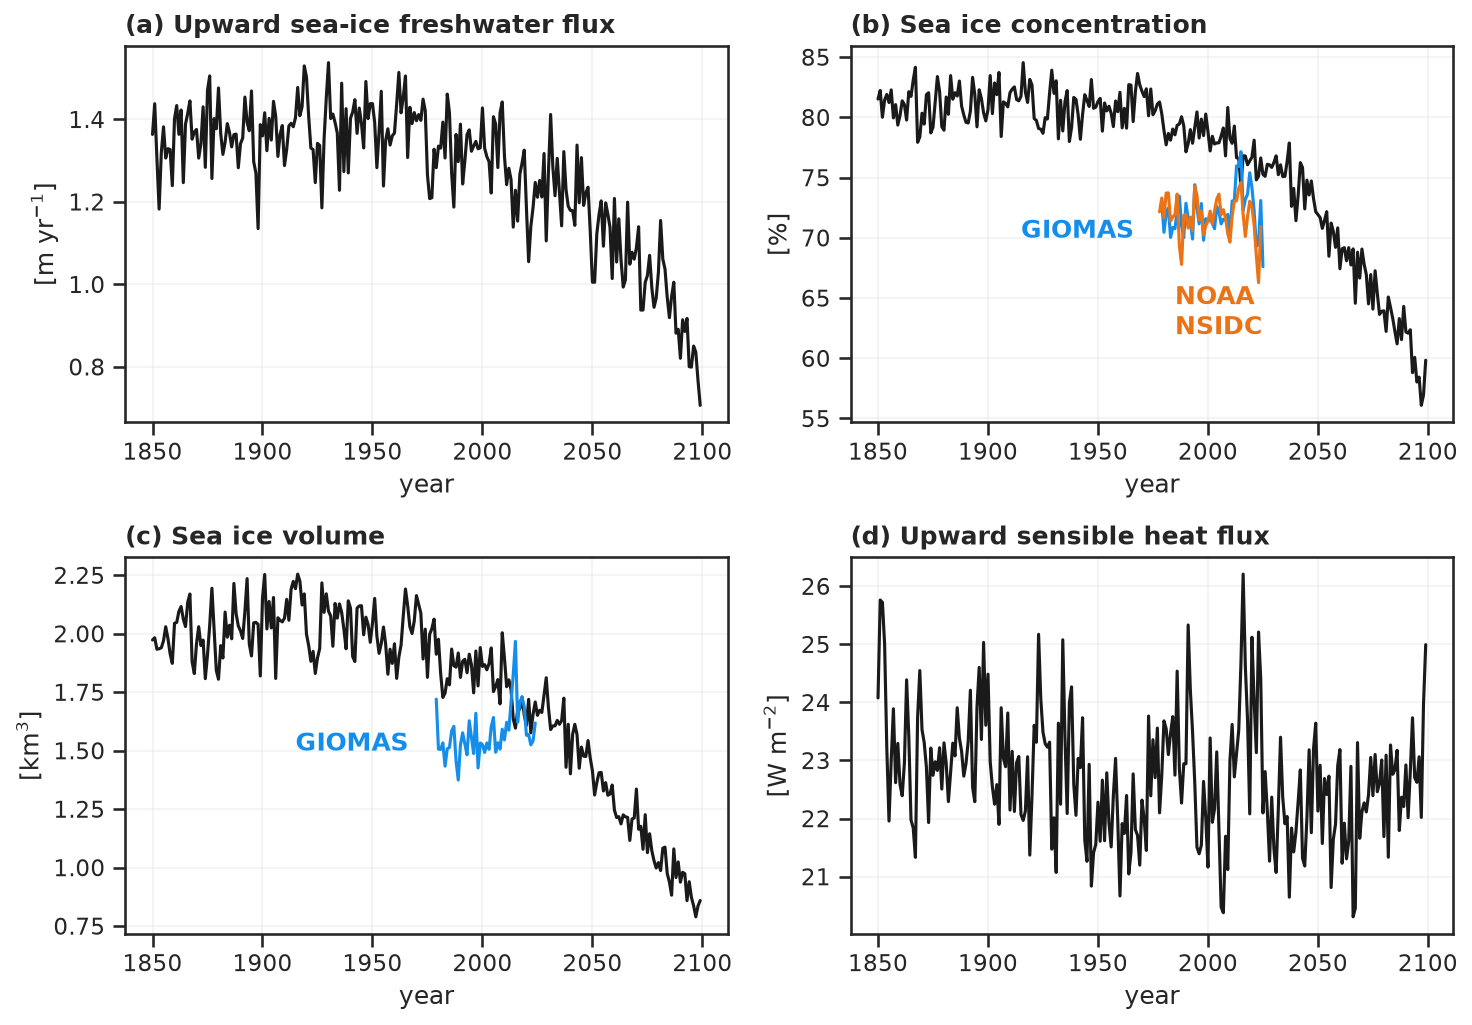

In [7]:
giomas_color = "#158EEB"
noaa_color = "#EB7215"

fig, axes = plt.subplots(2, 2, figsize=(10.0, 7.0))

ax = axes[0, 0]
fw_flux.plot(ax=ax, c="k")
ax.set_title("")
ax.set_title("(a) Upward sea-ice freshwater flux", fontweight="bold", loc="left")
ax.set_ylabel(r"[m yr$^{-1}$]")

ax = axes[0, 1]
siconc.plot(ax=ax, c="k")
siconc_giomas.plot(ax=ax, c=giomas_color)
siconc_noaa.plot(ax=ax, c=noaa_color)
ax.set_title("")
ax.set_title("(b) Sea ice concentration", fontweight="bold", loc="left")
ax.set_ylabel(r"[$\%$]")
ax.text(1985, 62, "NOAA\nNSIDC", c=noaa_color, fontweight="bold", fontsize=12)
ax.text(1915, 70, "GIOMAS", c=giomas_color, fontweight="bold", fontsize=12)

ax = axes[1, 0]
sivol.plot(ax=ax, c="k")
sivol_giomas.plot(ax=ax, c=giomas_color)
ax.set_title("")
ax.set_title("(c) Sea ice volume", fontweight="bold", loc="left")
ax.set_ylabel(r"[km$^3$]")
ax.text(1915, 1.5, "GIOMAS", c=giomas_color, fontweight="bold", fontsize=12)

ax = axes[1, 1]
sensible.plot(ax=ax, c="k")
ax.set_title("")
ax.set_title("(d) Upward sensible heat flux", fontweight="bold", loc="left")
ax.set_ylabel(r"[W m$^{-2}$]")

fig.tight_layout()
[a.grid(alpha=0.2) for a in axes.flatten()]
fig.savefig(plotsdir("fig06_fluxes_on_dsw_outcrops.png"), dpi=350, bbox_inches="tight")